In [3]:
import uuid, sys
NOTEBOOK = "work_tommaso"
SESSION = uuid.uuid4().hex[:8]
print(NOTEBOOK, SESSION, sys.executable)


work_tommaso ed5f130e c:\Users\morio\anaconda3\envs\ifc\python.exe


In [4]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

In [5]:
from ifc.config import load_data_config, load_split_config, resolve_project_root
from pathlib import Path
import pandas as pd

data_cfg = load_data_config() 
split_cfg = load_split_config()  
train_path, test_path = data_cfg.resolve_paths()    
print(data_cfg,"\n")

print(f'training path:{train_path}, exists? {train_path.exists()}')
print(f'tets path:{test_path}, exists? {test_path.exists()}')

id_col, time_col, target = data_cfg.id_col, data_cfg.time_col, data_cfg.target_col

print(f"Company_id column: {id_col}\nFiscal_year column: {time_col}\nTarget column: {target}")

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("train_df:", train_df.shape)
print("test_df :", test_df.shape)


DataConfig(train_path=WindowsPath('data/processed/train_data.csv'), test_path=WindowsPath('data/processed/test_features.csv'), id_col='company_id', time_col='fiscal_year', target_col='revenue_change', drop_cols=['bankruptcy_next_year', 'financial_health_class']) 

training path:C:\Users\morio\OneDrive\Desktop\Projects\italian-financial-challenge\data\processed\train_data.csv, exists? True
tets path:C:\Users\morio\OneDrive\Desktop\Projects\italian-financial-challenge\data\processed\test_features.csv, exists? True
Company_id column: company_id
Fiscal_year column: fiscal_year
Target column: revenue_change
train_df: (11828, 30)
test_df : (5811, 27)


In [6]:
train_df[[time_col,target]].describe().T

,count,mean,std,min,25%,50%,75%,max
fiscal_year,11828.0,2019.49535,1.116482,2018.00,2018.00,2019.00,2020.00,2021.00
revenue_change,8829.0,453.43457,4601.920625,-99.94,-68.59,3.04,238.85,302126.48


In [7]:
test_df[time_col].describe().T

count    5811.000000
mean     2022.498193
std         0.500040
min      2022.000000
25%      2022.000000
50%      2022.000000
75%      2023.000000
max      2023.000000
Name: fiscal_year, dtype: float64

In [8]:
unique_id = train_df[id_col].nunique()
unique_id_percentage = unique_id/len(train_df[id_col])

print(f'unique IDs:{unique_id}')
print(f'unique id percentage:{unique_id_percentage}')

unique IDs:2999
unique id percentage:0.25355089617855936


In [9]:
def missing_summary(df):
    missing_values = df.isnull().sum()
    missing_pct = (missing_values / len(df)) * 100

    missing_df = pd.DataFrame({
        'Missing Count': missing_values,
        'Percentage': missing_pct
    })
    missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
    return missing_df




In [10]:
missing_train = missing_summary(train_df)
print("Missing Values train:")
print(missing_train)

Missing Values train:
                Missing Count  Percentage
revenue_change           2999   25.355090
province                  919    7.769699
roe                        45    0.380453
leverage                   45    0.380453


In [11]:
missing_test = missing_summary(test_df)
print("Missing Values test")
print(missing_test)

Missing Values test
          Missing Count  Percentage
province            451    7.761143
roe                  14    0.240922
leverage             14    0.240922


In [12]:
key = [id_col, time_col]

dup_train = train_df.duplicated(subset=key).sum()
print("dup_train:", dup_train)

dup_test = test_df.duplicated(subset=key).sum()
print("dup_test:", dup_test)

if dup_train > 0:
    display(train_df.loc[train_df.duplicated(subset=key, keep=False), key].sort_values(key).head(20))

if dup_test > 0:
    display(test_df.loc[test_df.duplicated(subset=key, keep=False), key].sort_values(key).head(20))


dup_train: 0
dup_test: 0


In [13]:

df = train_df.copy()

first_year = df.groupby("company_id")["fiscal_year"].min()
df = df.join(first_year.rename("first_year"), on="company_id")

missing_in_first = df.loc[df["revenue_change"].isna() & (df["fiscal_year"] == df["first_year"])].shape[0]
missing_total = df["revenue_change"].isna().sum()

missing_not_first = df.loc[df["revenue_change"].isna() & (df["fiscal_year"] != df["first_year"])].shape[0]

print("missing_total:", missing_total)
print("missing_in_first_year:", missing_in_first)
print("missing_not_first_year (anomalies):", missing_not_first)

if missing_not_first > 0:
    display(df.loc[df["revenue_change"].isna() & (df["fiscal_year"] != df["first_year"]),
                   ["company_id","fiscal_year","first_year","production_value"]].head(20))


missing_total: 2999
missing_in_first_year: 2999
missing_not_first_year (anomalies): 0


In [14]:
train_cols = set(train_df.columns)
test_cols = set(test_df.columns)

only_in_train = sorted(list(train_cols - test_cols))
only_in_test = sorted(list(test_cols - train_cols))

print("Only in train:", only_in_train)
print("Only in test :", only_in_test)


Only in train: ['bankruptcy_next_year', 'financial_health_class', 'revenue_change']
Only in test : []


In [15]:
years = sorted(train_df[time_col].unique())
print("years_in_train_df:", years)

# counts per year
print(train_df[time_col].value_counts().sort_index())


years_in_train_df: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]
fiscal_year
2018    2961
2019    2979
2020    2956
2021    2932
Name: count, dtype: int64


# Data split

In [16]:
from ifc.split import apply_forecasting_holdout_split, build_forecasting_test_frame

df_train, df_val = apply_forecasting_holdout_split(train_df, split_cfg, drop_cols=data_cfg.drop_cols)
df_test_forecast = build_forecasting_test_frame(train_df, test_df, split_cfg, drop_cols=data_cfg.drop_cols)

print("df_train_forecast:", df_train.shape, "years:", sorted(df_train[time_col].unique()))
print("df_val_forecast  :", df_val.shape, "years:", sorted(df_val[time_col].unique()))
print("df_test_forecast :", df_test_forecast.shape, "years:", sorted(df_test_forecast[time_col].unique()))

df_train_forecast: (5897, 28) years: [np.int64(2019), np.int64(2020)]
df_val_forecast  : (2932, 28) years: [np.int64(2021)]
df_test_forecast : (5811, 27) years: [np.int64(2022), np.int64(2023)]


In [17]:
df_train.head()


,company_id,fiscal_year,revenue_change,prev_province,prev_region,prev_ateco_sector,prev_legal_form,prev_years_in_business,prev_total_fixed_assets,prev_current_assets,...,prev_financial_income,prev_financial_expenses,prev_net_profit_loss,prev_roe,prev_roi,prev_leverage,prev_current_ratio,prev_quick_ratio,prev_debt_to_assets,prev_profit_margin
1,COMP_00000,2019,-76.77,NaN,Campania,47.0,SRL,32.0,2.422343e+08,9.504819e+08,...,4886785.12,20068071.29,2.152049e+08,0.5772,0.1973,2.1987,1.6967,1.0180,0.6874,0.1165
2,COMP_00000,2020,1521.81,NaN,Campania,47.0,SRL,33.0,3.983639e+07,1.411226e+08,...,58246.06,2537224.20,3.677495e+07,0.6451,0.2172,2.1743,1.9778,1.1867,0.6850,0.0857
5,COMP_00001,2019,287.89,CA,Sardegna,62.0,SRL,8.0,8.348035e+07,1.325697e+08,...,640538.94,5860639.22,1.423603e+07,0.2168,0.0930,2.2900,1.7484,1.0490,0.6960,0.0346
6,COMP_00001,2020,-88.55,CA,Sardegna,62.0,SRL,9.0,3.073529e+08,6.198199e+08,...,866498.44,19304798.48,4.520087e+07,0.2293,0.0696,3.7038,1.8612,1.1167,0.7874,0.0283
9,COMP_00002,2019,1865.41,BA,Puglia,41.0,SAS,35.0,3.906155e+07,2.581125e+07,...,9342.13,978717.47,4.222250e+06,0.1388,0.0802,1.1332,1.2336,0.7401,0.5312,0.0857


In [18]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
fiscal_year,5897.0,2.019501e+03,5.000408e-01,2.019000e+03,2.019000e+03,2.020000e+03,2.020000e+03,2.020000e+03
revenue_change,5897.0,4.358499e+02,3.474444e+03,-9.994000e+01,-6.920000e+01,1.100000e+00,2.381900e+02,2.130303e+05
prev_ateco_sector,5897.0,4.583856e+01,1.669567e+01,1.000000e+01,4.100000e+01,4.600000e+01,5.600000e+01,8.200000e+01
prev_years_in_business,5897.0,3.429625e+01,1.982691e+01,0.000000e+00,1.700000e+01,3.400000e+01,5.100000e+01,6.900000e+01
prev_total_fixed_assets,5897.0,9.674398e+08,5.112752e+09,1.656874e+06,7.314590e+07,1.886777e+08,5.185635e+08,1.505032e+11
prev_current_assets,5897.0,1.395298e+09,6.747800e+09,3.983805e+06,1.240835e+08,3.043228e+08,8.119364e+08,2.432396e+11
prev_total_assets,5897.0,2.362738e+09,1.130449e+10,5.640679e+06,2.085633e+08,5.114180e+08,1.363677e+09,3.303010e+11
prev_shareholders_equity,5897.0,8.803351e+08,4.254840e+09,1.630662e+06,7.235638e+07,1.804049e+08,4.896262e+08,1.340870e+11
prev_total_debt,5897.0,1.482403e+09,7.356449e+09,2.989752e+06,1.289376e+08,3.137864e+08,8.450043e+08,2.441621e+11
prev_short_term_debt,5897.0,8.250488e+08,4.298247e+09,1.520389e+06,6.935150e+07,1.684216e+08,4.629355e+08,1.593762e+11


# train dataset analysis

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import seaborn as sns

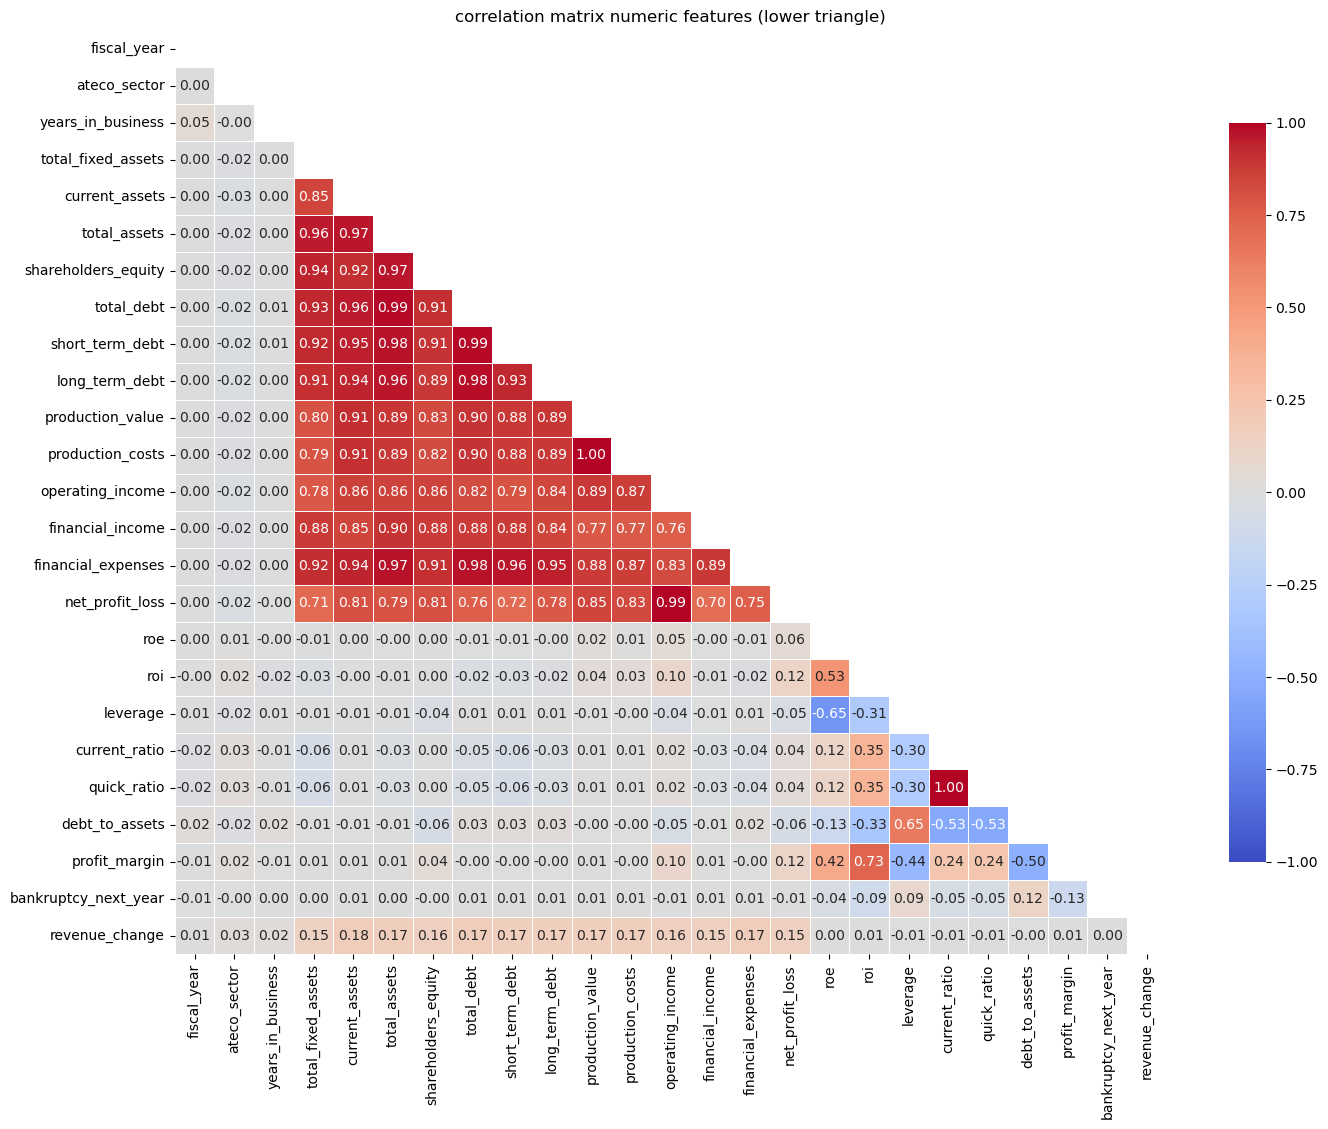

In [20]:
numeric_cols = train_df.select_dtypes(include=np.number).columns
correlation_matrix = train_df[numeric_cols].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(16,12))
sns.heatmap(correlation_matrix,
            mask= mask,
            fmt= ".2f",
            annot=True, 
            cmap='coolwarm',
            vmax= 1, vmin= -1,
                        
            linewidths=.5,       
            cbar_kws={"shrink": .8}) 
            
plt.title('correlation matrix numeric features (lower triangle)')
plt.show()

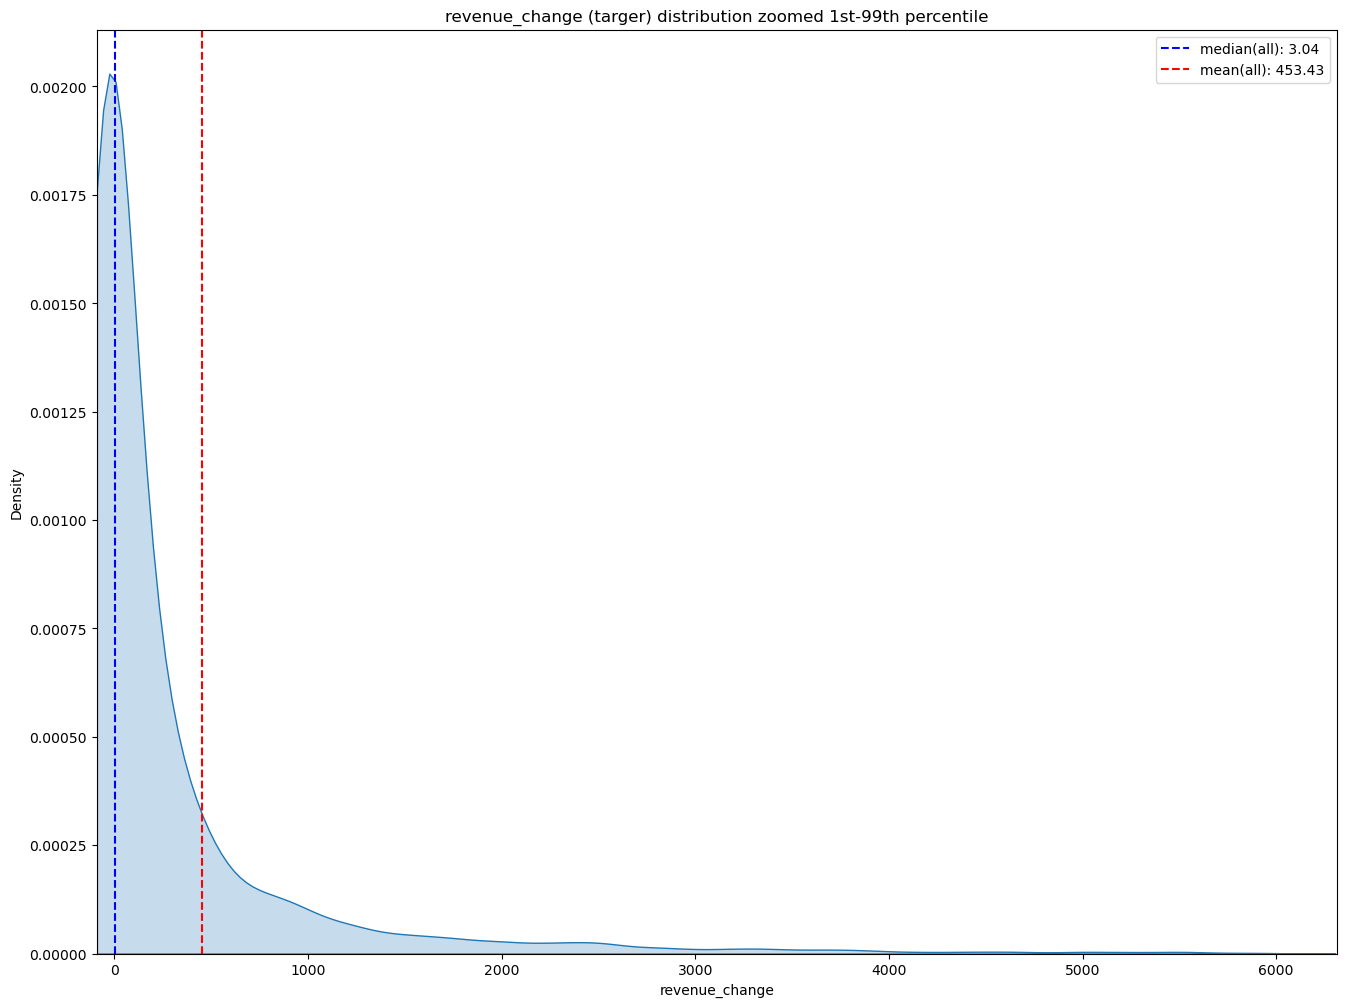

In [21]:
y = train_df[target].dropna().copy()
r_low, r_high = y.quantile([0.1, 0.99])
y_core = y[(y >= r_low) & (y <= r_high)]

plt.figure(figsize=(16,12))
sns.kdeplot(x=y_core, fill=True, cut=0)
plt.axvline(y.median(), color="blue", linestyle="--", label=f"median(all): {y.median():.2f}")
plt.axvline(y.mean(),   color="red",  linestyle="--", label=f"mean(all): {y.mean():.2f}")
plt.xlim(r_low, r_high)
plt.title('revenue_change (targer) distribution zoomed 1st-99th percentile')
plt.legend()
plt.show()


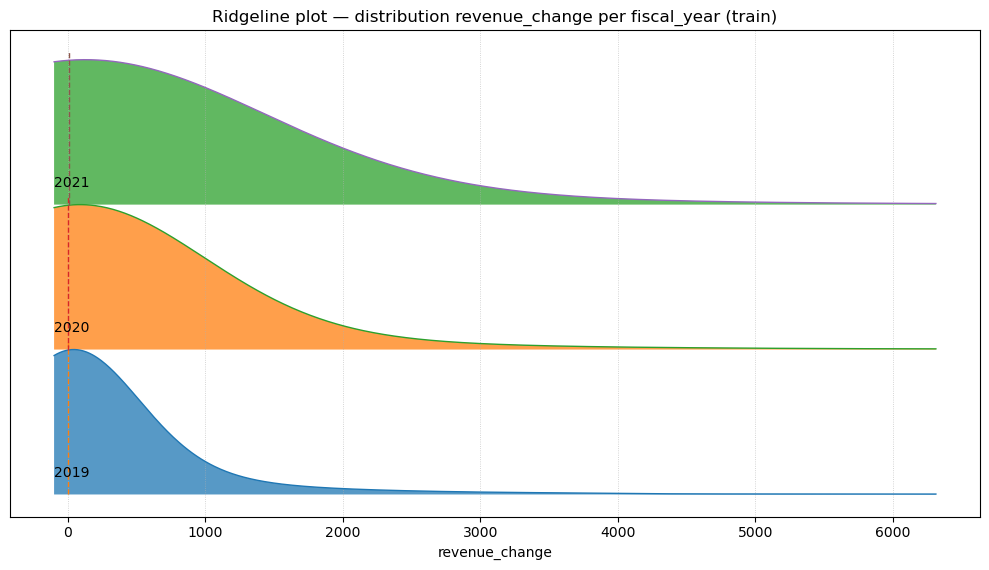

In [22]:


df = train_df[np.isfinite(train_df["revenue_change"])].copy()

years = sorted(df["fiscal_year"].unique())

x_low, x_high = np.percentile(df["revenue_change"], [0, 99])
x = np.linspace(x_low, x_high, 600)

fig, ax = plt.subplots(figsize=(10, 1.6 * len(years) + 1))
gap = 1.0

for i, y in enumerate(years):
    vals = df.loc[df["fiscal_year"] == y, "revenue_change"].to_numpy()
    vals = vals[np.isfinite(vals)]   # sicurezza extra

    
    if len(vals) < 10 or np.std(vals) == 0:
        
        med = np.median(vals) if len(vals) else np.nan
        offset = i * gap
        if np.isfinite(med):
            ax.plot([med, med], [offset, offset + 0.8], linestyle="--", linewidth=1.2)
            ax.text(x_low, offset + 0.1, str(y), va="bottom", ha="left")
        continue

    kde = gaussian_kde(vals)
    dens = kde(x)
    dens = dens / dens.max()

    offset = i * gap
    ax.fill_between(x, offset, offset + dens, alpha=0.75)
    ax.plot(x, offset + dens, linewidth=1.0)

    med = np.median(vals)
    ax.plot([med, med], [offset, offset + 1.05], linestyle="--", linewidth=1.0)

    ax.text(x_low, offset + 0.1, str(y), va="bottom", ha="left")

ax.set_title("Ridgeline plot — distribution revenue_change per fiscal_year (train)")
ax.set_xlabel("revenue_change")
ax.set_yticks([])
ax.grid(axis="x", linestyle=":", linewidth=0.6, alpha=0.7)
plt.tight_layout()
plt.show()

In [23]:

def p25(x): return x.quantile(0.25)
def p75(x): return x.quantile(0.75)
def p90(x): return x.quantile(0.90)
def p95(x): return x.quantile(0.95)
def p99(x): return x.quantile(0.99)


tmp = train_df[[time_col, target]].copy()

metrics = tmp.groupby(time_col)[target].agg([
    'count', 
    'mean', 
    'median', 
    p25, 
    p75, 
    p90, 
    p95, 
    p99
])

# Opzionale: arrotondamento per leggibilità

print(metrics.round(2))

             count   mean  median    p25     p75     p90      p95      p99
fiscal_year                                                               
2018             0    NaN     NaN    NaN     NaN     NaN      NaN      NaN
2019          2941  396.5    1.82 -68.38  242.26  872.97  1753.54  6787.59
2020          2956  475.0    0.34 -69.50  231.29  895.66  1722.46  7079.24
2021          2932  488.8    7.50 -67.35  240.05  884.68  1767.23  5181.84


# Macro-economics trend analysis

In [24]:
years = [2018, 2019, 2020, 2021]
tmp = train_df[train_df[time_col].isin(years)].copy()

tmp = tmp.replace([np.inf, -np.inf], np.nan)

def safe_div(a, b, eps=1e-9):
    return a / (b.replace(0, np.nan) + eps)

tmp["current_assets_share"] = safe_div(tmp["current_assets"], tmp["total_assets"])
tmp["st_debt_share"] = safe_div(tmp["short_term_debt"], tmp["total_debt"])
tmp["lt_debt_share"] = safe_div(tmp["long_term_debt"], tmp["total_debt"])
tmp["interest_burden"] = safe_div(tmp["financial_expenses"], tmp["total_debt"])
tmp["op_margin"] = safe_div(tmp["operating_income"], tmp["production_value"])

candidate = [
    "current_ratio", "quick_ratio",
    "debt_to_assets", "leverage",
    "profit_margin", "roi", "roe",
    "current_assets_share", "st_debt_share", "lt_debt_share",
    "interest_burden", "op_margin"
]

# tieni solo colonne esistenti
candidate = [c for c in candidate if c in tmp.columns]

def year_summary(col):
    s = tmp[["fiscal_year", col]].dropna()
    g = s.groupby("fiscal_year")[col]
    out = g.agg(
        n="count",
        mean='mean',
        median="median",
        p25=lambda x: np.percentile(x, 25),
        p75=lambda x: np.percentile(x, 75),
    )
    out["iqr"] = out["p75"] - out["p25"]
    return out

# score “informativeness” = shift robusto / iqr (quanto cambia il centro rispetto alla dispersione)
rows = []
for col in candidate:
    summ = year_summary(col)
    if not all(y in summ.index for y in [2019, 2020, 2021]):
        continue

    med19, med20, med21 = summ.loc[2019, "median"], summ.loc[2020, "median"], summ.loc[2021, "median"]
    iqr19 = summ.loc[2019, "iqr"] if summ.loc[2019, "iqr"] != 0 else np.nan
    iqr20 = summ.loc[2020, "iqr"] if summ.loc[2020, "iqr"] != 0 else np.nan

    shift_20_19 = (med20 - med19) / iqr19
    shift_21_20 = (med21 - med20) / iqr20

    rows.append({
        "feature": col,
        "median_2019": med19,
        "median_2020": med20,
        "median_2021": med21,
        "robust_shift_20_vs_19": shift_20_19,
        "robust_shift_21_vs_20": shift_21_20,
        "score_total_abs": np.nan_to_num(abs(shift_20_19)) + np.nan_to_num(abs(shift_21_20))
    })

rank = pd.DataFrame(rows).sort_values("score_total_abs", ascending=False)
rank.head(12)

,feature,median_2019,median_2020,median_2021,robust_shift_20_vs_19,robust_shift_21_vs_20,score_total_abs
5,roi,0.104100,0.106100,0.101400,0.017897,-0.044235,0.062132
6,roe,0.216050,0.223400,0.214600,0.025415,-0.032424,0.057839
1,quick_ratio,1.093600,1.094900,1.076950,0.002635,-0.037297,0.039931
0,current_ratio,1.822600,1.824800,1.794950,0.002675,-0.037216,0.039891
4,profit_margin,0.060700,0.060450,0.058500,-0.004205,-0.032911,0.037117
11,op_margin,0.077197,0.077137,0.075455,-0.000999,-0.028924,0.029923
10,interest_burden,0.035076,0.034736,0.034745,-0.022762,0.000584,0.023346
3,leverage,1.688100,1.700500,1.712650,0.009438,0.009116,0.018554
2,debt_to_assets,0.629200,0.630550,0.632000,0.007675,0.008293,0.015968
8,st_debt_share,0.547646,0.548596,0.549823,0.006356,0.008235,0.014591


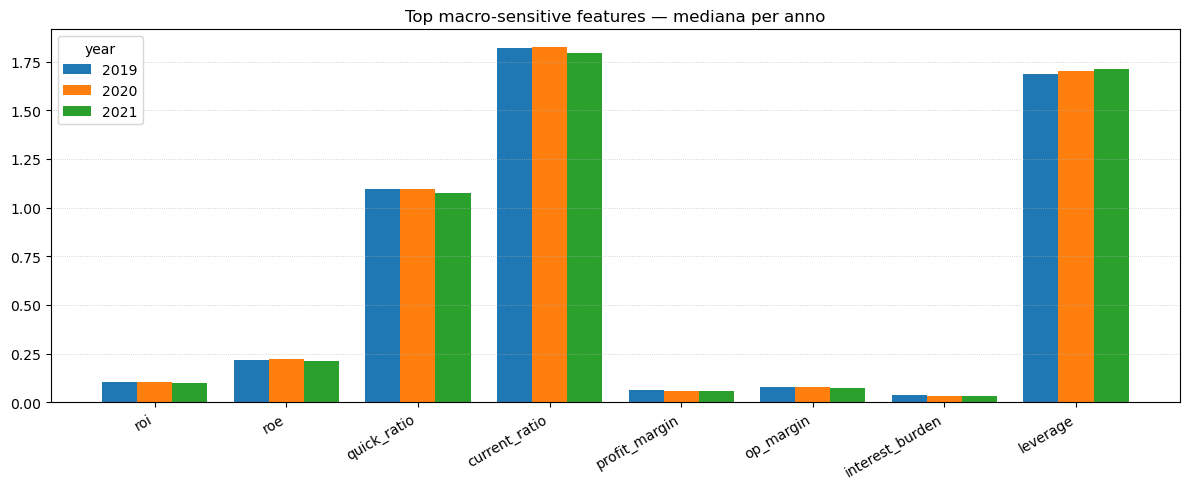

In [25]:


topk = 8
top_features = rank["feature"].head(topk).tolist()


med = (tmp[tmp["fiscal_year"].isin([2019,2020,2021])]
       .groupby("fiscal_year")[top_features]
       .median())

years_plot = med.index.tolist()
x = np.arange(len(top_features))
bar_w = 0.8 / len(years_plot)

plt.figure(figsize=(12, 5))
for i, y in enumerate(years_plot):
    plt.bar(x + i*bar_w, med.loc[y].to_numpy(), width=bar_w, label=str(y))

plt.xticks(x + bar_w*(len(years_plot)-1)/2, top_features, rotation=30, ha="right")
plt.title("Top macro-sensitive features — mediana per anno")
plt.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.7)
plt.legend(title="year")
plt.tight_layout()
plt.show()


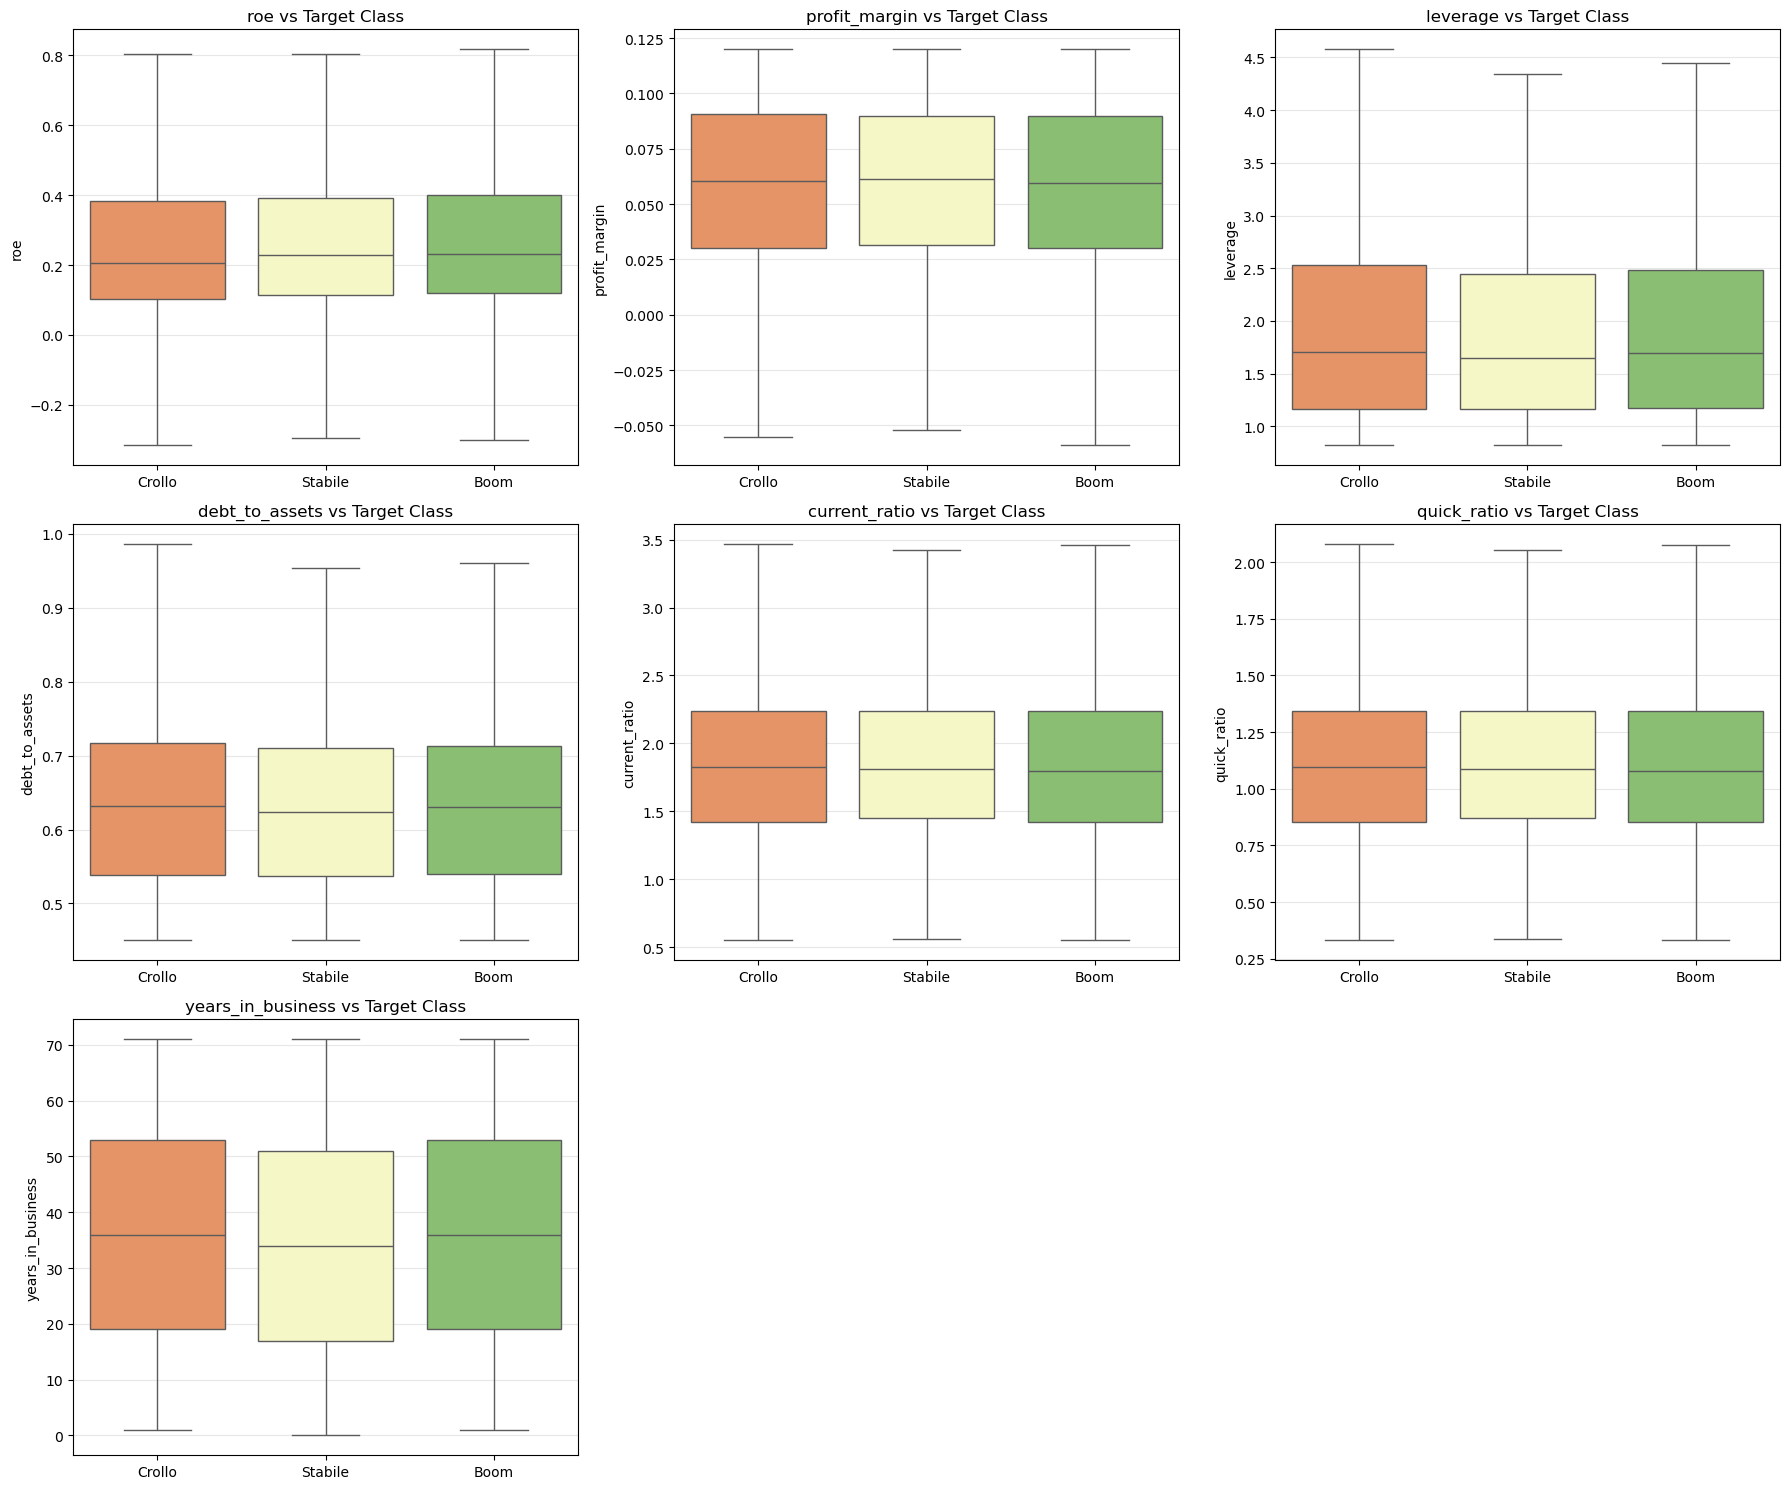

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

# 1. Ricrea le classi target (se non le hai già in memoria)
# Definiamo: CROLLO (< -10%), STABILE (tra -10% e +10%), BOOM (> +10%)
conditions = [
    train_df['revenue_change'] < -10,
    train_df['revenue_change'] > 10
]
choices = ['Crollo', 'Boom']
train_df['target_class'] = np.select(conditions, choices, default='Stabile')

# Ordiniamo le classi per logica visiva (dal male al bene)
order_classes = ['Crollo', 'Stabile', 'Boom']

# 2. Seleziona le feature da testare
# Includiamo i Ratios standard + quelli custom che hai calcolato prima + Years in Business
features_to_plot = [
    # Ratios Standard
    'roe', 'profit_margin', 'leverage', 'debt_to_assets', 
    'current_ratio', 'quick_ratio', 
    # Feature Strutturali / Custom (se presenti nel df)
    'years_in_business', 'current_assets_share', 'st_debt_share', 
    'lt_debt_share', 'interest_burden', 'op_margin'
]

# Filtra solo quelle che esistono davvero nel tuo dataframe
features_to_plot = [f for f in features_to_plot if f in train_df.columns]

# 3. Configurazione della Griglia Dinamica
n_cols = 3
n_rows = math.ceil(len(features_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    # Boxplot senza outliers estremi (showfliers=False) per vedere bene le mediane
    sns.boxplot(x='target_class', y=col, data=train_df, order=order_classes, 
                ax=axes[i], showfliers=False, palette="RdYlGn")
    
    axes[i].set_title(f'{col} vs Target Class')
    axes[i].set_xlabel('')
    axes[i].grid(axis='y', alpha=0.3)

# Rimuovi i grafici vuoti se ce ne sono
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 9) Company Age Analysis (Startup Volatility) Tommaso

**Feature**: `years_in_business`

**Output**
- Scatter plot: `years_in_business` vs `abs(revenue_change)` (or `revenue_change`)
- Table by Age Bucket (e.g., <5 years, 5-15 years, >15 years):
  - Median target, Standard Deviation of target

**Why**
- Hypothesis: Young companies (startups) have explosive growth/fail rates; mature companies are stable.

**Takeaway**
- “Younger companies show significantly higher volatility, suggesting `years_in_business` is a key segmentation feature for handling outliers.”

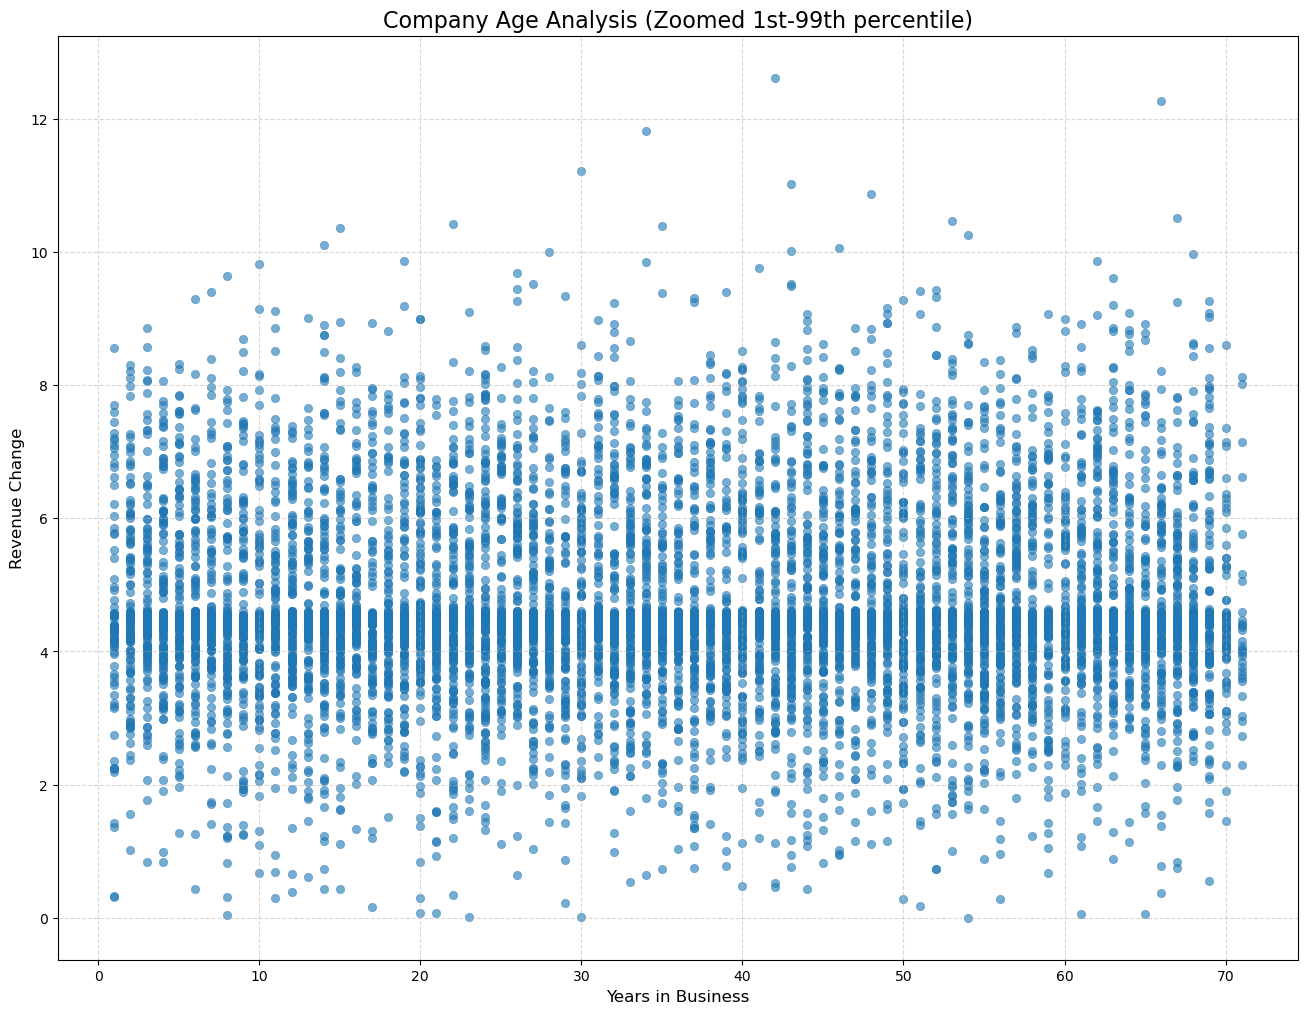

In [27]:


df = train_df.copy()


train_df['abs_rev_change'] = np.log1p(abs(train_df[target]))
plt.figure(figsize=(16, 12))

sns.scatterplot(data=train_df, x='years_in_business', y='abs_rev_change', alpha=0.6, edgecolor=None)



plt.title('Company Age Analysis (Zoomed 1st-99th percentile)', fontsize=16)
plt.xlabel('Years in Business', fontsize=12)
plt.ylabel('Revenue Change', fontsize=12) 
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [28]:
def year_buckets_summary(df, years = 'years_in_business'):
    tmp = df[[years,target]].dropna(subset=[years, target]).copy()

    # volatility
    tmp["y_abs"] = tmp[target].abs()

    buckets = {
        'startups(<5)' : tmp[tmp[years]<5]["y_abs"],
        'mid(5-15)' : tmp[(tmp[years]>=5) & (tmp[years] <= 15)]['y_abs'],
        'mature(>15)' : tmp[tmp[years]> 15]['y_abs'],
    }

    out = {}
    for bucket, v in buckets.items():
        out[bucket] = {
            'median' : v.median(),
            'std': v.std(),
            "p25": v.quantile(0.25),
            "p75": v.quantile(0.75),
            "p99": v.quantile(0.99),
            "n": v.shape[0],
        }
    
    return pd.DataFrame(out).T

summary = year_buckets_summary(train_df)

summary

,median,std,p25,p75,p99,n
startups(<5),85.24,758.389712,53.6025,274.8025,3722.4183,442.0
mid(5-15),85.16,1546.545080,48.7850,223.5750,6041.9002,1375.0
mature(>15),86.68,5106.907615,50.9675,240.5100,6675.6293,7012.0


### Company Age & Volatility (`years_in_business`)

**What we measured.** We analyzed volatility using `|revenue_change|` and summarized it by age buckets: **<5**, **5–15**, **>15** years.

**Key finding.** The **typical volatility** is very similar across age buckets:
- Medians are ~**85** in all groups.
- The central spread (IQR) is comparable across buckets.

**Where differences emerge.** The **tails** differ substantially:
- The **p99** of `|revenue_change|` increases with age (**~3.7k → 6.0k → 6.7k**), indicating that **extreme events are more pronounced among older firms**.

**Interpretation (hypothesis, not causal).** One possible driver is **one-off structural events** (e.g., **M&A / consolidations / divestitures**) that may be more common among older firms with more assets and resources. However, the dataset does **not** include a direct M&A indicator, so this remains speculative.


In [29]:

def mna_asset_cojump_analysis(
    df: pd.DataFrame,
    id_col: str,
    time_col: str,
    target_col: str = "revenue_change",
    pv_col: str = "production_value",
    assets_col: str = "total_assets",
    min_year: int = 2019,
    extreme_q: float = 0.99,         # p99 on |y|
    growth_q: float = 0.95,          # p95 on asset_growth
    denom_q: float = 0.10,           # p10 threshold for "non-tiny" denominators
    eps_denom: float = 1.0,          # guardrail for near-zero denominators
):
    """
    Step A: define extreme events on |revenue_change| (p99).
    Step B: compute asset co-jump via asset_growth = assets / assets_prev - 1.
    Step C: diagnose denominator effect via assets_prev quantiles and re-evaluate on non-tiny subset.
    """

    
    # 0) Build lag frame (DO NOT drop target here)
    cols_needed = [id_col, time_col, target_col, pv_col, assets_col]
    lag = df[cols_needed].copy()
    lag = lag.sort_values([id_col, time_col])

    lag["pv_prev"] = lag.groupby(id_col)[pv_col].shift(1)
    lag["assets_prev"] = lag.groupby(id_col)[assets_col].shift(1)

    # 1) Define analysis universe (years >= min_year, target not null)
    universe = lag[lag[time_col] >= min_year].copy()
    universe = universe.dropna(subset=[target_col])
    universe["abs_y"] = universe[target_col].abs()

    y_abs_thr = np.quantile(universe["abs_y"].to_numpy(), extreme_q)

    cands = universe[universe["abs_y"] >= y_abs_thr].copy()

    
    # 2) Compute asset_growth with robust denominator gates (assets_prev must be finite and > eps_denom; same for current assets)
    def _clean_growth_frame(frame: pd.DataFrame) -> pd.DataFrame:
        tmp = frame.dropna(subset=["assets_prev", assets_col]).copy()
        tmp = tmp[np.isfinite(tmp["assets_prev"]) & np.isfinite(tmp[assets_col])].copy()
        tmp = tmp[(tmp["assets_prev"] > eps_denom) & (tmp[assets_col] > 0)].copy()
        tmp["asset_growth"] = (tmp[assets_col] / tmp["assets_prev"]) - 1
        # remove inf/nan growth
        tmp = tmp[np.isfinite(tmp["asset_growth"])].copy()
        return tmp

    # Growth population should be comparable to candidates: same year filter and target non-null (so we compare against the same “modeling universe”)
    growth_pop = _clean_growth_frame(universe)
    cands_g = _clean_growth_frame(cands)

    asset_growth_thr = np.quantile(growth_pop["asset_growth"].to_numpy(), growth_q)
    cands_g["asset_jump"] = cands_g["asset_growth"] >= asset_growth_thr

    # 3) Denominator diagnostics (assets_prev quantiles) on the same growth population
    assets_prev_p05 = np.quantile(growth_pop["assets_prev"].to_numpy(), 0.05)
    assets_prev_p10 = np.quantile(growth_pop["assets_prev"].to_numpy(), denom_q)
    assets_prev_p25 = np.quantile(growth_pop["assets_prev"].to_numpy(), 0.25)

    cands_g["assets_prev_tiny"] = cands_g["assets_prev"] <= assets_prev_p10

    # 4) Stable subset re-evaluation (assets_prev > p10) + stable threshold
    growth_pop_stable = growth_pop[growth_pop["assets_prev"] > assets_prev_p10].copy()
    cands_stable = cands_g[cands_g["assets_prev"] > assets_prev_p10].copy()

    # guard: if stable pop is too small, avoid noisy quantiles
    if len(growth_pop_stable) > 50 and len(cands_stable) > 0:
        asset_growth_thr_stable = np.quantile(growth_pop_stable["asset_growth"].to_numpy(), growth_q)
        cands_stable["asset_jump_stable"] = cands_stable["asset_growth"] >= asset_growth_thr_stable
    else:
        asset_growth_thr_stable = np.nan
        cands_stable["asset_jump_stable"] = np.nan

    # 5) Outputs
    print(f"abs_y p{int(extreme_q*100)} threshold: {y_abs_thr}")
    print(f"n_candidates (raw): {len(cands)}  share%: {len(cands)/len(universe)*100:.3f}")

    print(f"asset_growth p{int(growth_q*100)} (global): {asset_growth_thr}")
    print(f"asset_jump share (cands): {cands_g['asset_jump'].mean():.3f}")

    print(f"assets_prev p05/p{int(denom_q*100)}/p25: {assets_prev_p05}  {assets_prev_p10}  {assets_prev_p25}")
    print(f"share assets_prev <= p{int(denom_q*100)} in candidates: {cands_g['assets_prev_tiny'].mean():.3f}")

    print(f"n_non_tiny: {len(cands_stable)}  share: {len(cands_stable)/len(cands_g):.3f}")
    print(f"asset_growth p{int(growth_q*100)} (stable): {asset_growth_thr_stable}")
    if cands_stable["asset_jump_stable"].notna().all():
        print(f"asset_jump_stable share (non-tiny): {cands_stable['asset_jump_stable'].mean():.3f}")

    top_cols = [id_col, time_col, target_col, "abs_y", pv_col, "pv_prev",
                assets_col, "assets_prev", "asset_growth", "asset_jump", "assets_prev_tiny"]
    print("\nTop 10 candidates by abs_y (with assets co-jump):")
    print(cands_g.sort_values("abs_y", ascending=False)[top_cols].head(10))

    return {
        "lag": lag,
        "universe": universe,
        "candidates_raw": cands,
        "candidates_with_growth": cands_g,
        "candidates_non_tiny": cands_stable,
        "thresholds": {
            "y_abs_thr": y_abs_thr,
            "asset_growth_thr": asset_growth_thr,
            "assets_prev_p10": assets_prev_p10,
            "asset_growth_thr_stable": asset_growth_thr_stable,
        }
    }

res = mna_asset_cojump_analysis(
    train_df,
    id_col=id_col,
    time_col=time_col,
    target_col=target,
    pv_col="production_value",
    assets_col="total_assets",
    min_year=2019,
    extreme_q=0.99,
    growth_q=0.95,
    denom_q=0.10,
    eps_denom=1.0,
)


abs_y p99 threshold: 6313.31359999999
n_candidates (raw): 89  share%: 1.008
asset_growth p95 (global): 15.838127538759146
asset_jump share (cands): 1.000
assets_prev p05/p10/p25: 62374840.158  95175661.30800001  208419852.72
share assets_prev <= p10 in candidates: 0.506
n_non_tiny: 44  share: 0.494
asset_growth p95 (stable): 10.599246718030866
asset_jump_stable share (non-tiny): 1.000

Top 10 candidates by abs_y (with assets co-jump):
       company_id  fiscal_year  revenue_change      abs_y  production_value  \
9793   COMP_02485         2021       302126.48  302126.48      1.012812e+11   
380    COMP_00096         2020       213030.29  213030.29      1.034987e+10   
5876   COMP_01490         2021       136091.65  136091.65      1.232272e+10   
8571   COMP_02174         2019        74020.61   74020.61      1.752024e+10   
11557  COMP_02932         2019        61346.04   61346.04      1.893038e+10   
3543   COMP_00896         2021        52783.86   52783.86      7.208317e+10   
1765   C

### M&A-like Signals from Financial Statements (Explaining Extreme `revenue_change`)

**Goal.** We looked for *indirect* signals of extraordinary events (e.g., consolidation / M&A / perimeter changes) behind the most extreme values of `revenue_change`, using only accounting variables available in the dataset.

---

#### 1) Candidate “extreme events” selection (Top 1%)
We defined extreme observations as the **top 1%** of `|revenue_change|` (years **≥ 2019**, non-null target).

- **Threshold:** `p99(|revenue_change|)` = **6313.31**
- **Candidates:** **89** rows (**~1.01%** of the eligible sample)

This yields a compact list of the most abnormal YoY revenue changes to investigate further.

---

#### 2) Co-jump test: do extreme revenue events coincide with a jump in firm scale?
We computed an **asset growth proxy**:

\[
\text{asset\_growth}_t = \frac{\text{total\_assets}_t}{\text{total\_assets}_{t-1}} - 1
\]

and compared candidates against the global distribution of `asset_growth`.

- **Global threshold:** `p95(asset_growth)` = **15.84**
- **Result:** **100%** of extreme revenue candidates also fall above this threshold  
  → extreme `|revenue_change|` is consistently accompanied by an extreme jump in `total_assets`.

---

#### 3) Denominator effect: are co-jumps driven by “tiny” prior-year assets?
Since ratio-based growth can explode when the prior-year denominator is small, we inspected the distribution of `total_assets_{t-1}`.

- `assets_prev` percentiles (global):  
  - **p05:** 62.37M  
  - **p10:** 95.18M  
  - **p25:** 208.42M
- Among the 89 candidates, **50.6%** have `assets_prev ≤ p10`  
  → about half of the extremes may be amplified by a low prior-year asset base.

---

#### 4) Stable-subset re-test (removing “tiny denominator” cases)
We re-evaluated the co-jump **only on candidates with non-tiny denominators** (`assets_prev > p10`), and recalculated the benchmark threshold on the same stable population.

- **Non-tiny candidates:** **44** rows (**~49.4%** of candidates)
- **Stable threshold:** `p95(asset_growth | assets_prev > p10)` = **10.60**
- **Result:** **100%** of non-tiny candidates still exceed the stable threshold

**Interpretation:** Even after controlling for denominator effects, extreme `|revenue_change|` events remain strongly associated with extreme increases in firm assets, suggesting **structural scale changes** rather than purely percentage artifacts.

---

#### 5) Conclusion (non-causal)
- Extreme `|revenue_change|` events (top 1%) show a robust **co-jump** with `total_assets`, and this persists even when excluding low-denominator cases.
- This pattern is **consistent with extraordinary structural events** such as **consolidation/M&A, perimeter changes, or major accounting reclassifications**, but **cannot be confirmed** without a dedicated M&A indicator.

---

#### Next step
Extend the same co-jump logic to financing channels to strengthen interpretation:
- `total_debt` growth (debt-funded events)
- `shareholders_equity` growth (equity-funded events)
- optional: short-term vs long-term debt mix shifts


## 10) Feature drift on 5 key variables (X drift) Tommaso

**Suggested 5 features**
- `production_value`, `total_assets`, `total_debt`, `operating_income`, `current_ratio`

**Output**
- Table by `fiscal_year` for each feature: median + p95 (or mean+std)
- Note any strong shifts in 2021 vs train years

**Why**
- Feature drift can explain performance drop in 2021.

**Takeaway**
- “Key financial drivers show (limited/material) drift across years, impacting 2021 generalization.”


In [30]:


drift_col = ['production_value','total_assets','total_debt','operating_income','current_ratio']


df_drift = train_df[[time_col] + drift_col].copy()
summary = df_drift.groupby(time_col)[drift_col].agg(['median', lambda s: s.quantile(0.95)])
summary.columns = [f"{c}_{s if s!='<lambda_0>' else 'p95'}" for c,s in summary.columns]


baseline_years = [2019, 2020]
baseline = summary.loc[baseline_years].mean()


delta_pct = (summary / baseline - 1) * 100
delta_pct = delta_pct.round(2)

delta_2021 = delta_pct.loc[[2021]]

display(delta_2021.style.background_gradient(axis=1))


,production_value_median,production_value_p95,total_assets_median,total_assets_p95,total_debt_median,total_debt_p95,operating_income_median,operating_income_p95,current_ratio_median,current_ratio_p95
fiscal_year,,,,,,,,,,
2021,8.380000,-7.390000,5.950000,1.480000,4.390000,1.700000,4.000000,-14.550000,-1.580000,-0.400000


In [31]:

rank = delta_2021.T.rename(columns={2021: "delta_%"}).copy()
rank["abs_delta_%"] = rank["delta_%"].abs()
rank = rank.sort_values("abs_delta_%", ascending=False)
rank["drift_flag"] = np.where(rank["abs_delta_%"] >= 10, "MATERIAL (>=10%)", "limited")

display(rank)


fiscal_year,delta_%,abs_delta_%,drift_flag
operating_income_p95,-14.55,14.55,MATERIAL (>=10%)
production_value_median,8.38,8.38,limited
production_value_p95,-7.39,7.39,limited
total_assets_median,5.95,5.95,limited
total_debt_median,4.39,4.39,limited
operating_income_median,4.00,4.00,limited
total_debt_p95,1.70,1.70,limited
current_ratio_median,-1.58,1.58,limited
total_assets_p95,1.48,1.48,limited
current_ratio_p95,-0.40,0.40,limited


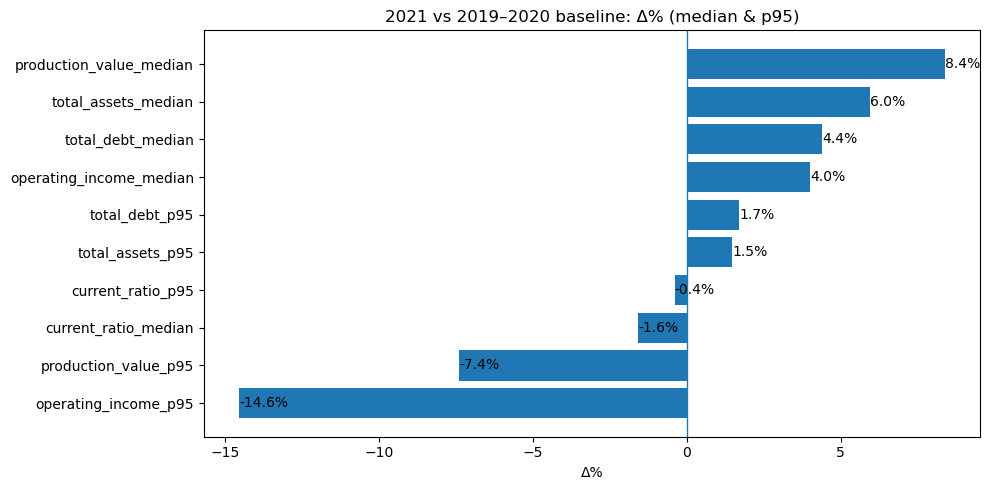

In [32]:


plot_df = rank.sort_values("delta_%")  # o abs_delta_% se preferisci

plt.figure(figsize=(10, 5))
plt.barh(plot_df.index, plot_df["delta_%"])
plt.axvline(0, linewidth=1)

# etichette %
for i, v in enumerate(plot_df["delta_%"].values):
    plt.text(v, i, f"{v:.1f}%", va="center")

plt.title("2021 vs 2019–2020 baseline: Δ% (median & p95)")
plt.xlabel("Δ%")
plt.tight_layout()
plt.show()


### Feature drift (X drift) — 2021 vs 2019–2020 baseline

We summarized 5 key features by `fiscal_year` using **median** and **p95**, then computed **Δ% for 2021 vs the 2019–2020 baseline**.

**Main findings (ranked by |Δ%|):**
- **operating_income_p95:** **-14.6%** (largest drift) → the upper tail of profitability is materially lower in 2021.
- **production_value_median:** **+8.4%** → typical firm scale increases in 2021.
- **production_value_p95:** **-7.4%** → the upper tail of revenue is lower in 2021.
- Other shifts are mild: `total_assets_median` (+6.0%), `total_debt_median` (+4.4%), `operating_income_median` (+4.0%); `current_ratio` is almost stable.

**Takeaway.**
Overall drift is **limited in medians**, but **more pronounced in the upper tail**, especially for `operating_income`. This tail-drift may contribute to weaker generalization on 2021 compared to training years (2019–2020).


In [33]:

# 1) Lavoriamo solo dove il target esiste (2018 è tipicamente NaN)
df = train_df.loc[train_df["revenue_change"].notna()].copy()

# 2) Soglia statistica: top 1% per |revenue_change|
p99_abs = df["revenue_change"].abs().quantile(0.99)

# 3) Flag "business" dal data dictionary + flag "tail"
df["flag_pos_100"] = df["revenue_change"] > 100
df["flag_neg_80"]  = df["revenue_change"] < -80
df["flag_tail_99"] = df["revenue_change"].abs() > p99_abs

flags = ["flag_pos_100", "flag_neg_80", "flag_tail_99"]

# 4) Quanti casi prende ogni flag?
counts = df[flags].sum().astype(int).rename("count").to_frame()
counts["pct_of_nonnull_target"] = (counts["count"] / len(df)).round(4)

print("P99(|revenue_change|) =", p99_abs)
display(counts)

# 5) Overlap: combinazioni dei 3 flag (quante righe in ciascun pattern)
overlap = (
    df.groupby(flags)
      .size()
      .rename("n")
      .reset_index()
      .sort_values("n", ascending=False)
)

# Tieni solo i pattern che esistono (n>0)
overlap = overlap[overlap["n"] > 0].copy()
overlap["pct"] = (overlap["n"] / len(df)).round(4)

display(overlap)

# 6) (Optional ma utile) Overlap 2x2 rapido
display(pd.crosstab(df["flag_pos_100"], df["flag_tail_99"]))
display(pd.crosstab(df["flag_neg_80"],  df["flag_tail_99"]))


P99(|revenue_change|) = 6313.31359999999


,count,pct_of_nonnull_target
flag_pos_100,3130,0.3545
flag_neg_80,1573,0.1782
flag_tail_99,89,0.0101


,flag_pos_100,flag_neg_80,flag_tail_99,n,pct
0,False,False,False,4126,0.4673
2,True,False,False,3041,0.3444
1,False,True,False,1573,0.1782
3,True,False,True,89,0.0101


flag_tail_99,False,True
flag_pos_100,,
False,5699,0
True,3041,89


flag_tail_99,False,True
flag_neg_80,,
False,7167,89
True,1573,0


In [34]:
df = train_df.loc[train_df["revenue_change"].notna()].copy()

qs = [0.995, 0.99, 0.98, 0.975, 0.95]
rows = []
for q in qs:
    thr = df["revenue_change"].abs().quantile(q)
    n = (df["revenue_change"].abs() > thr).sum()
    rows.append({"quantile": q, "threshold": thr, "n": int(n), "pct": n/len(df)})

sens = pd.DataFrame(rows).sort_values("quantile", ascending=False)
display(sens)


,quantile,threshold,n,pct
0,0.995,9947.7900,45,0.005097
1,0.990,6313.3136,89,0.010080
2,0.980,3541.7936,177,0.020048
3,0.975,2995.8300,221,0.025031
4,0.950,1755.8420,442,0.050062


In [35]:

# --- Base: solo righe con target disponibile ---
df = train_df.loc[train_df["revenue_change"].notna()].copy()
df = df.sort_values(["company_id", "fiscal_year"])

# --- P98 su |revenue_change| (unico tier) ---
abs_rc = df["revenue_change"].abs()
p98 = abs_rc.quantile(0.98)
df["is_p98"] = abs_rc > p98

# --- Asset growth YoY ---
df["assets_prev"] = df.groupby("company_id")["total_assets"].shift(1)
df["asset_growth"] = np.where(
    (df["assets_prev"].notna()) & (df["assets_prev"] > 0),
    df["total_assets"] / df["assets_prev"] - 1,
    np.nan
)
asset_p95 = df.loc[df["asset_growth"].notna(), "asset_growth"].quantile(0.95)
df["cojump_assets"] = df["asset_growth"] > asset_p95

# --- Debt growth YoY ---
df["debt_prev"] = df.groupby("company_id")["total_debt"].shift(1)
df["debt_growth"] = np.where(
    (df["debt_prev"].notna()) & (df["debt_prev"] > 0),
    df["total_debt"] / df["debt_prev"] - 1,
    np.nan
)
debt_p95 = df.loc[df["debt_growth"].notna(), "debt_growth"].quantile(0.95)

# Robust: se debt_prev ~0 e ora >0, consideralo jump
eps = 1e-9
df["debt_prev_zero_jump"] = (df["debt_prev"].notna()) & (df["debt_prev"] <= eps) & (df["total_debt"] > eps)
df["cojump_debt"] = (df["debt_growth"] > debt_p95) | df["debt_prev_zero_jump"]

# --- TRI-JUMP (scala + funding nello stesso anno) ---
df["tri_jump"] = df["cojump_assets"] & df["cojump_debt"]

print("p98(|revenue_change|) =", p98)
print("p95(asset_growth)    =", asset_p95)
print("p95(debt_growth)     =", debt_p95)

# --- Summary P98 + tri-jump ---
summary = pd.DataFrame({
    "n_total": [len(df)],
    "n_p98": [int(df["is_p98"].sum())],
    "p98_share": [df["is_p98"].mean()],
    "n_p98_tri": [int((df["is_p98"] & df["tri_jump"]).sum())],
    "p98_tri_share_within_p98": [((df["is_p98"] & df["tri_jump"]).sum() / df["is_p98"].sum()) if df["is_p98"].sum() else np.nan],
    "tri_share_outside_p98": [df.loc[~df["is_p98"], "tri_jump"].mean()],
})
display(summary)

# --- Elenco ordinato dei candidati (P98) con tri-jump prima ---
cols = [
    "company_id", "fiscal_year",
    "revenue_change", "total_assets", "assets_prev", "asset_growth",
    "total_debt", "debt_prev", "debt_growth",
    "tri_jump"
]

candidates = df.loc[df["is_p98"], cols].copy()
candidates = candidates.sort_values(
    by=["tri_jump", "revenue_change"],
    ascending=[False, False]
)

display(candidates.head(50))  # top 50: prima i tri-jump


p98(|revenue_change|) = 3541.793600000002
p95(asset_growth)    = 15.898251346592229
p95(debt_growth)     = 16.50430785395351


,n_total,n_p98,p98_share,n_p98_tri,p98_tri_share_within_p98,tri_share_outside_p98
0,8829,177,0.020048,112,0.632768,0.016759


,company_id,fiscal_year,revenue_change,total_assets,assets_prev,asset_growth,total_debt,debt_prev,debt_growth,tri_jump
9793,COMP_02485,2021,302126.48,5.680029e+10,5.203086e+07,1090.665421,3.258190e+10,3.540806e+07,919.182916,True
380,COMP_00096,2020,213030.29,5.446688e+09,5.640679e+06,964.608583,3.857977e+09,2.989752e+06,1289.400341,True
5876,COMP_01490,2021,136091.65,7.759461e+09,1.433322e+07,540.362129,5.147274e+09,1.021078e+07,503.102057,True
3543,COMP_00896,2021,52783.86,3.842508e+10,1.763094e+08,216.941142,2.568254e+10,8.310548e+07,308.035457,True
1765,COMP_00450,2020,36912.64,8.088873e+09,3.089255e+07,260.838995,4.917641e+09,2.207943e+07,221.724997,True
11471,COMP_02910,2020,34995.72,2.091662e+11,6.084652e+08,342.760350,1.400967e+11,2.993592e+08,466.988523,True
2959,COMP_00749,2020,32622.00,2.877681e+10,1.990209e+08,143.591892,2.122820e+10,1.217021e+08,173.427536,True
5700,COMP_01445,2020,31430.96,1.523334e+11,3.676139e+08,413.384195,1.198555e+11,2.135305e+08,560.303881,True
6868,COMP_01742,2020,28415.86,6.667845e+09,2.787835e+07,238.176473,4.300235e+09,1.740632e+07,246.050150,True
8450,COMP_02143,2020,23255.88,1.850222e+10,6.808787e+07,270.740314,1.161337e+10,4.904803e+07,235.775408,True


In [37]:
from ifc.data_quality import run_all_checks_readable

report = run_all_checks_readable(train_df, test_df, verbose=True)
report["summary"]



DATA QUALITY SUMMARY (PASS/WARN/FAIL)
                                             check status
        No duplicate keys (company_id,fiscal_year)   PASS
           Target missing only for first-year rows   PASS
       Target formula matches production_value lag   PASS
            No missing in raw balance/income items   PASS
                           No inf values in ratios   PASS
Accounting identity holds (assets ≈ equity + debt)   PASS
       No multi-year exact zeros in key scale vars   PASS

OVERVIEW
 dup_train  dup_test              years_train   years_test  n_train  n_test  n_companies_train  n_companies_test
         0         0 [2018, 2019, 2020, 2021] [2022, 2023]    11828    5811               2999              2916

TARGET MISSINGNESS (expected: only first year)
 n_missing_target  n_first_obs  missing_not_first  first_not_missing  perfect_match
             2999         2999                  0                  0           True

TARGET FORMULA CHECK (abs diff in percentage

,check,status
0,"No duplicate keys (company_id,fiscal_year)",PASS
1,Target missing only for first-year rows,PASS
2,Target formula matches production_value lag,PASS
3,No missing in raw balance/income items,PASS
4,No inf values in ratios,PASS
5,Accounting identity holds (assets ≈ equity + d...,PASS
6,No multi-year exact zeros in key scale vars,PASS


In [43]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

ID_COL="company_id"
TIME_COL="fiscal_year"
TARGET="revenue_change"

FEATURES = [
    "production_value","total_assets","total_debt","current_assets","shareholders_equity",
    "operating_income","net_profit_loss",
    "current_ratio","debt_to_assets","leverage"
]

def y_slog(y):
    return np.sign(y) * np.log1p(np.abs(y))

def single_feature_lift_test(df, features=FEATURES):
    d = df.sort_values([ID_COL, TIME_COL]).copy()

    # y_next = revenue_change_{t+1}
    d["y_next"] = d.groupby(ID_COL)[TARGET].shift(-1)

    # split: train = x_2018->y_2019 and x_2019->y_2020 ; val = x_2020->y_2021
    train_mask = d[TIME_COL].isin([2018, 2019]) & d["y_next"].notna()
    val_mask   = d[TIME_COL].eq(2020) & d["y_next"].notna()

    y_train = y_slog(d.loc[train_mask, "y_next"].values)
    y_val   = y_slog(d.loc[val_mask, "y_next"].values)

    # baseline = mean on train
    y_pred_base = np.full_like(y_val, fill_value=y_train.mean(), dtype=float)
    rmse_base = mean_squared_error(y_val, y_pred_base)

    rows = []
    for f in features:
        if f not in d.columns:
            continue

        x_tr = d.loc[train_mask, f].replace([np.inf,-np.inf], np.nan).astype(float)
        x_va = d.loc[val_mask, f].replace([np.inf,-np.inf], np.nan).astype(float)

        # drop NaNs (feature-specific)
        tr_ok = x_tr.notna()
        va_ok = x_va.notna()

        # need some data
        if tr_ok.sum() < 500 or va_ok.sum() < 200:
            continue

        X_train = x_tr[tr_ok].to_numpy().reshape(-1,1)
        Y_train = y_train[tr_ok.to_numpy()]
        X_val   = x_va[va_ok].to_numpy().reshape(-1,1)
        Y_val   = y_val[va_ok.to_numpy()]

        # standardize using train stats (important)
        mu = X_train.mean()
        sd = X_train.std()
        sd = sd if sd > 1e-12 else 1.0
        X_train = (X_train - mu) / sd
        X_val   = (X_val - mu) / sd

        model = Ridge(alpha=1.0, random_state=0)
        model.fit(X_train, Y_train)
        pred = model.predict(X_val)

        rmse = mean_squared_error(Y_val, pred)
        lift = (rmse_base - rmse) / rmse_base

        rows.append({
            "feature": f,
            "n_train": int(len(Y_train)),
            "n_val": int(len(Y_val)),
            "rmse_base": float(rmse_base),
            "rmse_feat": float(rmse),
            "lift_pct": float(lift*100),
        })

    out = pd.DataFrame(rows).sort_values("lift_pct", ascending=False).reset_index(drop=True)
    return out

# USO:
tbl_lift = single_feature_lift_test(train_df)
tbl_lift


,feature,n_train,n_val,rmse_base,rmse_feat,lift_pct
0,production_value,5897,2932,23.590034,23.108461,2.041425
1,current_assets,5897,2932,23.590034,23.110920,2.031003
2,total_debt,5897,2932,23.590034,23.207090,1.623329
3,operating_income,5897,2932,23.590034,23.257620,1.409131
4,net_profit_loss,5897,2932,23.590034,23.290981,1.267711
5,total_assets,5897,2932,23.590034,23.310046,1.186891
6,shareholders_equity,5897,2932,23.590034,23.468446,0.515422
7,current_ratio,5897,2932,23.590034,23.577863,0.051593
8,leverage,5897,2932,23.590034,23.586788,0.013760
9,debt_to_assets,5897,2932,23.590034,23.590725,-0.002928
